In [31]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

import random 
np.random.seed(0)

In [32]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [33]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [34]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [35]:
set(y_train)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

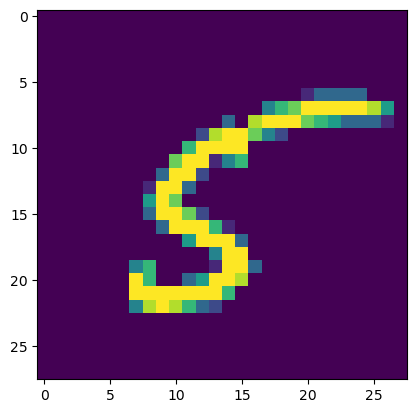

In [36]:
plt.imshow(x_train[y_train == 5][50])
plt.show()

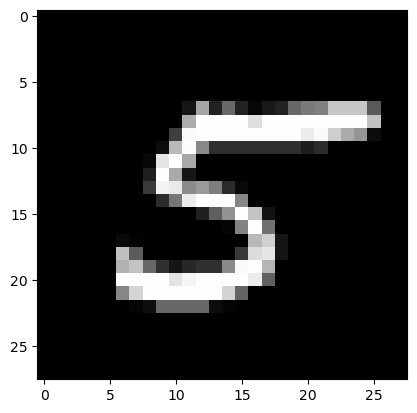

In [37]:
plt.imshow(x_train[y_train == 5][4700],cmap = 'gray')
plt.show()

In [8]:
for i in range(0,10):
    print(i, ';', len(x_train[y_train]))

0 ; 60000
1 ; 60000
2 ; 60000
3 ; 60000
4 ; 60000
5 ; 60000
6 ; 60000
7 ; 60000
8 ; 60000
9 ; 60000


In [9]:
len(y_train[0:101:]==5)

101

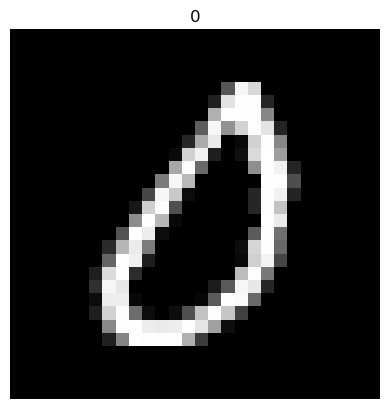

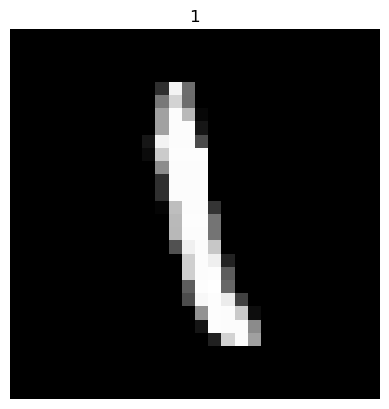

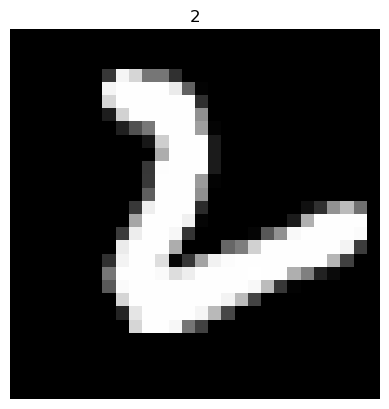

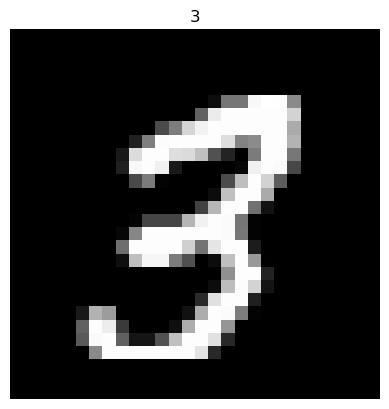

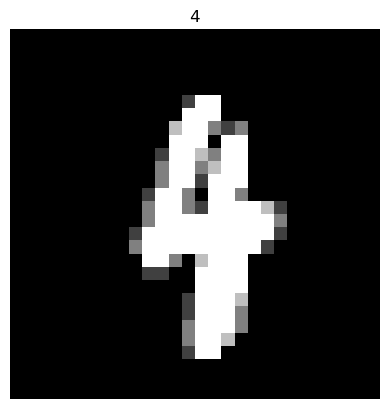

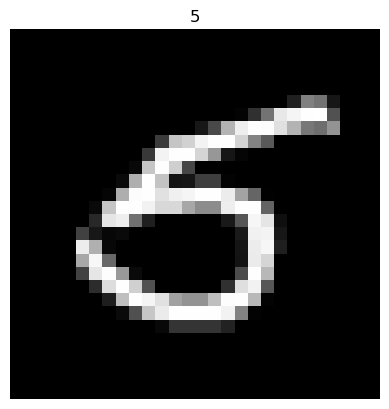

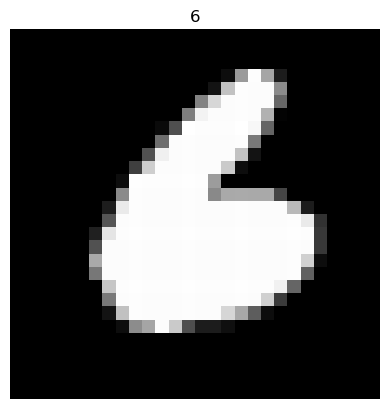

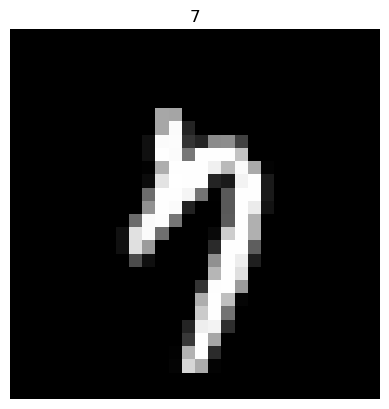

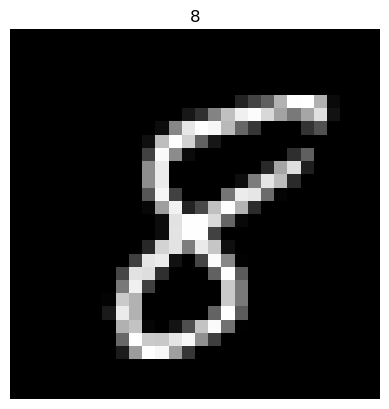

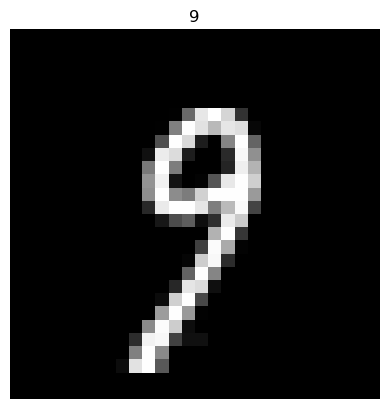

In [10]:
for i in range(0,10):
    plt.imshow(x_train[y_train==i][np.random.randint(0,5400)],cmap = 'gray')
    plt.title(str(i))
    plt.axis('off')
    plt.show()

In [11]:
# to_categorical 
from keras.utils import to_categorical

In [12]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [13]:
x_train = x_train/255
x_test = x_test/255

In [14]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [15]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [16]:
x_train.shape

(60000, 28, 28)

In [17]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)

In [18]:
x_train.shape

(60000, 784)

In [19]:
model = Sequential()
model.add(Dense(35,input_dim = 784,activation = 'relu'))
model.add(Dense(15,activation = 'relu'))
model.add(Dense(25,activation = 'relu'))
model.add(Dense(10,activation = 'softmax'))
model.compile(Adam(learning_rate=0.01),loss = 'categorical_crossentropy',metrics = ['accuracy'] )

/Users/nexusop03/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 35)             │        27,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,675 (112.01 KB)

 Trainable params: 28,675 (112.01 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.fit(x_train,y_train,validation_split=0.1,epochs = 10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 517us/step - accuracy: 0.8989 - loss: 0.3462 - val_accuracy: 0.9500 - val_loss: 0.1817
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 471us/step - accuracy: 0.9413 - loss: 0.2130 - val_accuracy: 0.9367 - val_loss: 0.2274
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 464us/step - accuracy: 0.9484 - loss: 0.1884 - val_accuracy: 0.9587 - val_loss: 0.1485
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 456us/step - accuracy: 0.9551 - loss: 0.1709 - val_accuracy: 0.9578 - val_loss: 0.1510
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 449us/step - accuracy: 0.9573 - loss: 0.1580 - val_accuracy: 0.9580 - val_loss: 0.1589
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step - accuracy: 0.9599 - loss: 0.1496 - val_accuracy: 0.9608 - val_loss: 0.1604
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step - accuracy: 0.9629 - loss: 0.1420 - val_accuracy: 0.9620 - val_loss: 0.1619
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 451us/step - accuracy: 0.9640 -

In [22]:
pred = model.predict(x_test)
pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step


array([[5.5391337e-07, 2.4907780e-09, 4.2885581e-06, ..., 9.9985129e-01,
        9.5667860e-07, 1.3328648e-04],
       [6.4785857e-11, 1.4593672e-07, 9.9999666e-01, ..., 1.3167704e-06,
        2.1168793e-08, 2.0583186e-16],
       [3.1432233e-19, 9.9999857e-01, 9.1006953e-09, ..., 3.6102193e-07,
        8.7493498e-07, 3.2647240e-10],
       ...,
       [5.1692380e-13, 2.1692803e-07, 1.7138774e-08, ..., 1.2183253e-10,
        4.3092080e-14, 2.1872765e-07],
       [3.6949352e-06, 2.3607538e-10, 2.5441305e-14, ..., 6.5744347e-11,
        7.8019104e-05, 2.1555879e-10],
       [5.4746261e-09, 2.4534846e-10, 1.2640817e-12, ..., 3.9190022e-30,
        1.3145080e-11, 9.7193261e-23]], dtype=float32)

# 25th July

In [23]:
import cv2
import matplotlib.pyplot as plt

In [24]:
img = cv2.imread('/Users/nexusop03/Downloads/6MNIST.jpeg')

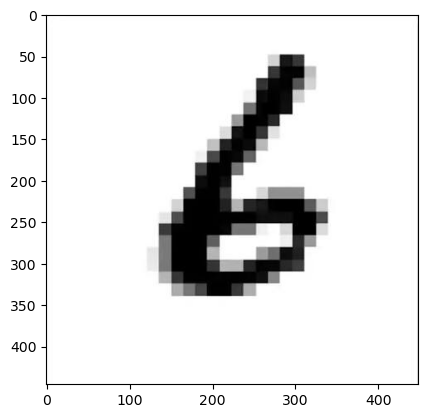

In [25]:
plt.imshow(img, cmap = 'gray')
plt.show()

In [26]:
img.shape

(446, 448, 3)

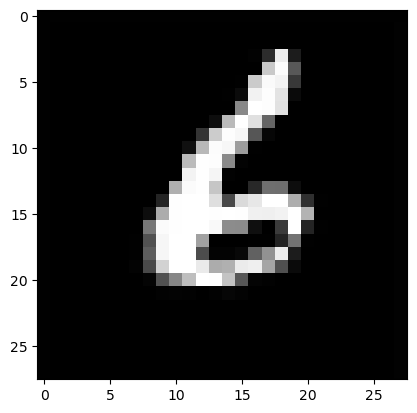

In [27]:
img = cv2.resize(img,(28,28))
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) # cv2.bitwise_not :- Ye white background ko black aur black background ko white mein convert karne mein help karta hai
img = cv2.bitwise_not(img)
plt.imshow(img,cmap = 'gray')
plt.show()

In [28]:
img = img/255
img = img.reshape(1,784)

In [29]:
pred = model.predict(img)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[2.0074465e-05, 2.7520657e-06, 1.0680548e-07, 8.0999989e-09,
        4.1435401e-06, 3.8006350e-05, 9.9993420e-01, 4.1540713e-18,
        7.6727287e-07, 1.5109619e-13]], dtype=float32)

In [38]:
p = np.argmax(pred,axis = 1)
print(p[0])

6
